# 1 Likelihood Based Analysis of the 21-cm Power Spectrum
## a) PCA

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np  
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import optuna
import torch
from torch import nn, optim
import tqdm
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
from helpers.load_files import load_splits
from helpers.set_seed import set_seed

set_seed(1701)
data_dir = Path("simulations")
raw_data = load_splits(data_dir)

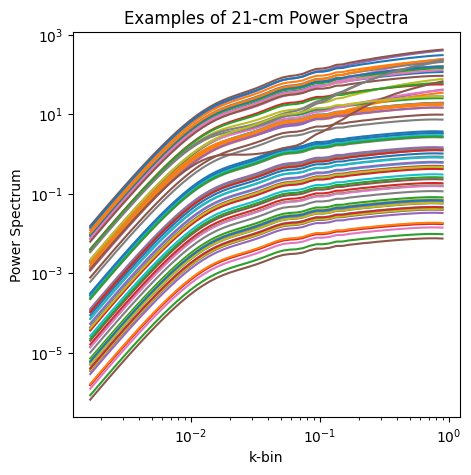

In [3]:
# Plot the power spectra examples
plt.figure(figsize=(5, 5))
for i in  range(0, 8000, 100):
    plt.loglog(raw_data['k_train'][i], raw_data['power_train'][i], label=f'Sim {i+1}')
plt.xlabel('k-bin')
plt.ylabel('Power Spectrum')
plt.title('Examples of 21-cm Power Spectra')
# plt.legend()
plt.show()

- We must normalise the training parameters as they can have different scales with respect to one another. We don't want to bias the trained NN based on the various input scales so we can scale them using a StandardScaler, which brings the mean to 0 and variance to 1.
- Each power spectrum mode has a different scale. For PCA, we want to find meaningful variations, not just the largest magnitude variations, which can be a result of different component scales. A component can have little relative variance in its axis but a huge absolute variance because of scale. As such, we normalise our power spectra as well.
- Since the power spectra vary across several orders of magnitude, it is prudent to work with the logarithm.

In [4]:
from helpers.preprocess import preprocess
processed = preprocess(raw_data, n_comp=6, log_power=True)

- Now we apply PCA on this data

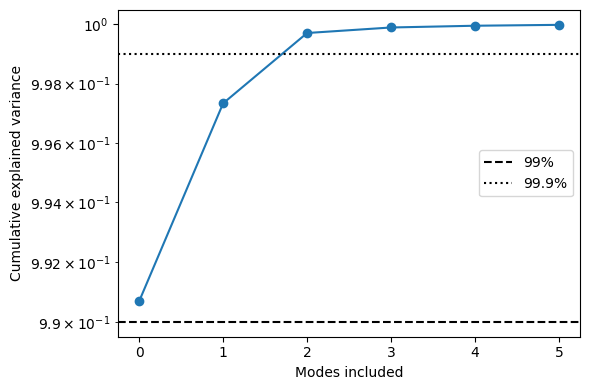

In [5]:
evecs = processed['W']
explained_variance_ratio = processed['explained_variance_ratio']
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance ratio
plt.figure(figsize=(6,4))
plt.yscale('log')
plt.plot(cumulative_explained_variance, marker='o')
plt.axhline(0.99, ls='--', c='k', label='99%')
plt.axhline(0.999, ls=':', c='k', label='99.9%')
plt.xlabel("Modes included")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
thresholds = [0.99, 0.999, 0.9999]
for threshold in thresholds:
    n = np.searchsorted(cumulative_explained_variance, threshold) + 1
    print(f"{100 * threshold:.8f}% threshold explained by first {n} components")

99.00000000% threshold explained by first 1 components
99.90000000% threshold explained by first 3 components
99.99000000% threshold explained by first 5 components


- This tells us that the first three eigenvectors are all we need to describe a significant majority of the variance in the data.  It will be valid to compress the training data down using just the first three eigenvectors. 
- However, the explained variance does not correspond directly to emulator accuracy. There are a few more factors to consider:
    - The emulated likelihood may depend on some rare features which only appear in the extremes of some parameter. Because the feature is rare, this leaves a very low variance footprint in the PCA.
    - The emulated likelihood may depend on some small scale feature which looks very small in absolute variance terms.
    - The training set may not be completely representative. Some features appearing in the validation set might not appear here.
- It would not cost too much more to perform the analysis with a few more components for safety.

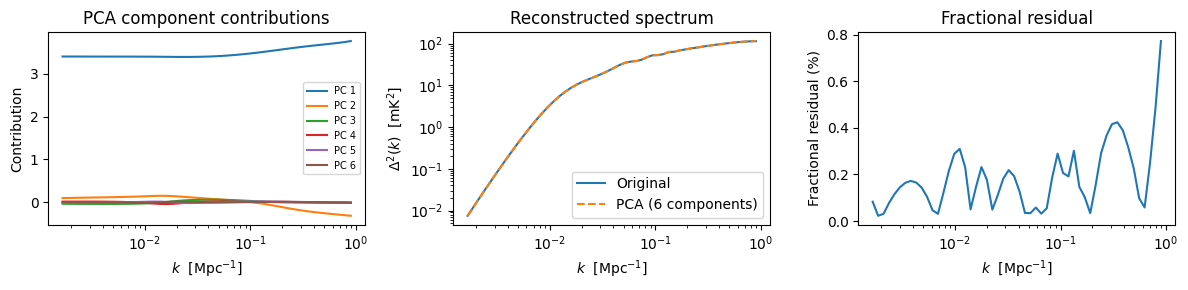

In [ ]:
n_comp =6
from helpers.plotting import plot_reconstructed_train
_ = plot_reconstructed_train(processed, raw_data, n_comp=n_comp, plot=True, idx=0)

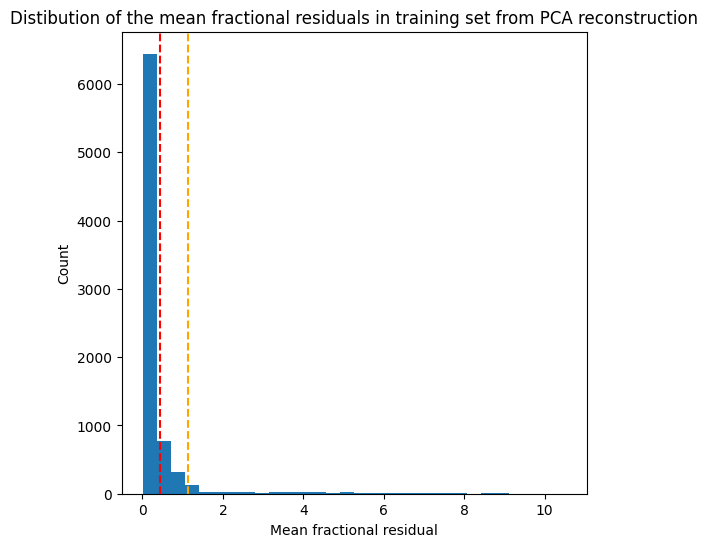

Mean fractional residual: 0.43%
95th percentile of fractional residuals: 1.14%


In [9]:
# Plot fractional residual distribution for PCA reconstruction on training set
from helpers.plotting import pca_fractional_residual
_ = pca_fractional_residual(processed, raw_data, n_comp=n_comp)

# b) NN 



Unscaled:
Feature 0 has range 1.000e-01 to 9.999e+00 with mean 2.135e+00
Feature 1 has range 1.002e-03 to 9.996e-01 with mean 1.418e-01
Feature 2 has range 1.002e-03 to 9.995e-01 with mean 1.416e-01
Feature 3 has range 5.000e-01 to 1.000e+00 with mean 7.510e-01
Scaled:
Feature 0 has range -8.184e-01 to 3.163e+00 with mean 3.816e-09
Feature 1 has range -6.315e-01 to 3.848e+00 with mean -2.385e-09
Feature 2 has range -6.313e-01 to 3.854e+00 with mean -4.770e-10
Feature 3 has range -1.748e+00 to 1.735e+00 with mean 1.193e-08


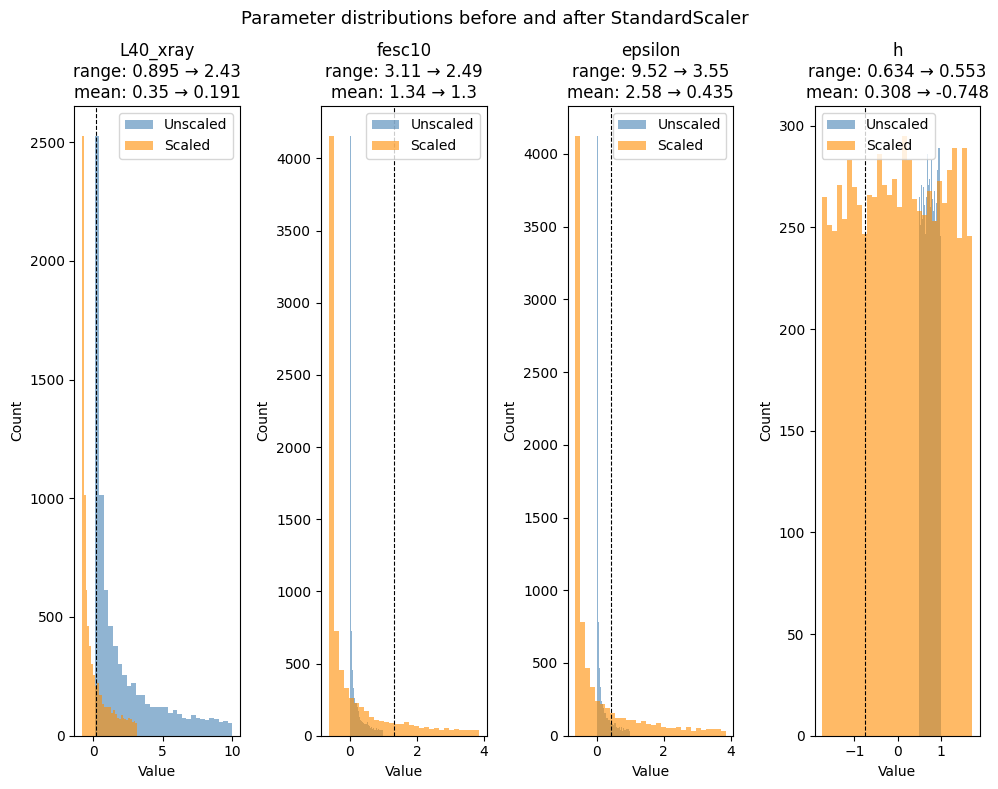

In [10]:
from helpers.plotting import plot_pca_train_weights

unscaled_feature_domains =  plot_pca_train_weights(processed,raw_data,n_comp=n_comp)


- We should normalise each one to to have zero mean and unit variance for best NN performance.

- This looks good. Now we train the NN. 
- We will train a fully connected model. 
- To determine the depth, width, and LR we will use for the model, I will run an optuna optimisation.
- All of this has been shifted to the optuna_optimize script.
- I will just reimport the model here. 

In [11]:
import pickle
from helpers.emulator import Emulator
from helpers.evaluate_model import evaluate_model

checkpoint = torch.load("optuna_outputs/local_run/best_model_run50_reconstruction_log_1.65pct.pt", 
                         map_location="cpu")

model = Emulator(
    input_dim=checkpoint["input_dim"],
    output_dim=checkpoint["output_dim"],
    hidden_dim=checkpoint["best_params"]["hidden_dim"],
    num_layers=checkpoint["best_params"]["num_layers"],
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

with open("optuna_outputs/local_run/preprocessing_run50_reconstruction_log_1.65pct.pkl", "rb") as f:
    preproc = pickle.load(f)

model_evaluation_data = evaluate_model(model, processed, raw_data, device="cpu")
print(f"The model mean frac error is {model_evaluation_data['mean_percentage_error']:.2f}%")
print(f"The model 95th percentile frac error is {model_evaluation_data['p95_percentage_error']:.2f}%")
print(f"The best parameters are {checkpoint['best_params']}")

The model mean frac error is 1.65%
The model 95th percentile frac error is 5.63%
The best parameters are {'num_layers': 3, 'hidden_dim': 128, 'lr': 0.004860645882927601, 'weight_decay': 1.0535946145298462e-05}


- Our best model is now stored as the best_model.
- We can now examing best_model's performance on the test set.

c:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\helpers\plotting.py:265: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


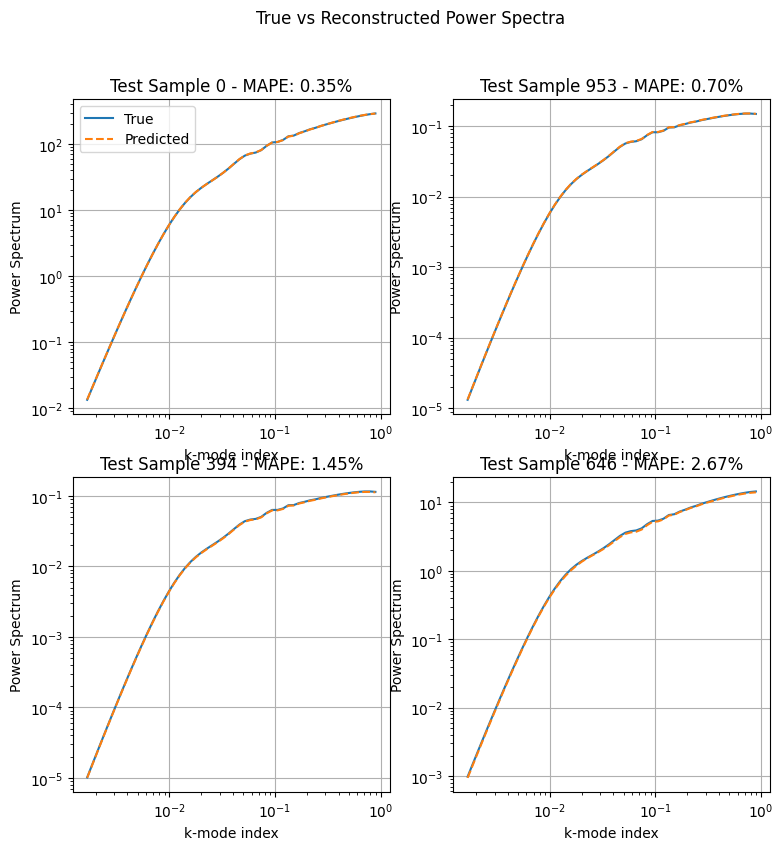

In [12]:
from helpers.plotting import plot_reconstructions

plot_reconstructions(model_evaluation_data, raw_data, 2)

This looks great!

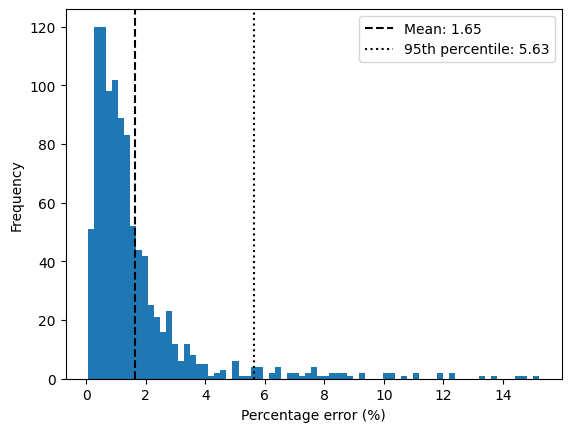

In [13]:
from helpers.plotting import plot_mape_distribution

plot_mape_distribution(model_evaluation_data)

## c)

In [15]:
observation_path= Path("observations/observations.npz")
with np.load(observation_path, allow_pickle=True) as d:
    observation = dict(d)


In [16]:
for k, (lo, hi) in unscaled_feature_domains.items():
    print(f"{k}: [{lo:.3g}, {hi:.3g}]  →  {np.log10(hi/lo):.1f} decades")

L40_xray: [0.1, 10]  →  2.0 decades
fesc10: [0.001, 1]  →  3.0 decades
epsilon: [0.001, 1]  →  3.0 decades
h: [0.5, 1]  →  0.3 decades


- This is pretty big. This motivates sampling in log space.

In [ ]:
from helpers.sampling import generate_chain
import json

run = False # Prevent this from running when run all is done
if run == True:
    ln_sampled_posterior = generate_chain(steps = 250000, discard = 0, unscaled_feature_domains=unscaled_feature_domains, model=model, 
                                   p_obs=observation['power'], processed=processed, tf=1)
    np.save("thinned_samples.npy",   ln_sampled_posterior["thinned_samples"]) #unflattened
    np.save("unthinned_samples.npy", ln_sampled_posterior["unthinned_samples"])
    with open("diagnostics.json", "w") as f:
        json.dump({
            "mean_frac": float(ln_sampled_posterior["mean_frac"]),
            "taus":      ln_sampled_posterior["taus"].tolist(),
            "mean_tau":  float(ln_sampled_posterior["mean_tau"]),
            "tau":       int(ln_sampled_posterior["tau"]),
        }, f, indent=2)


In [19]:
thinned_chain   = np.exp(np.load("thinned_samples.npy"))     # shape (steps, n_walkers, 5)
unthinned_chain   = np.exp(np.load("unthinned_samples.npy"))     # shape (steps, n_walkers, 5)
with open("diagnostics.json") as f:
    diag = json.load(f)

(250000, 32, 5)
(7968000, 5)


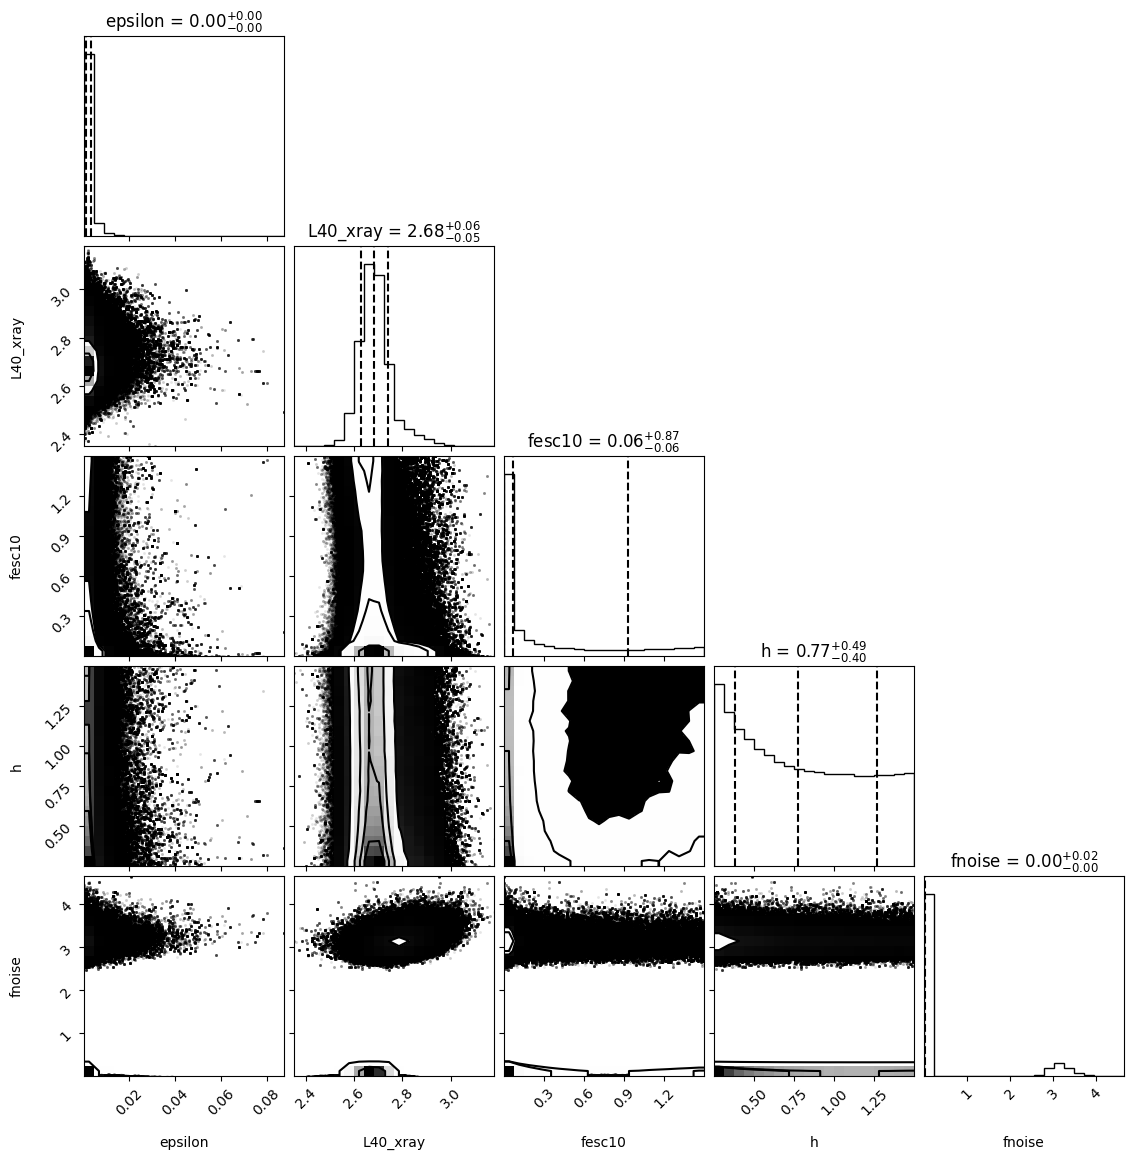

In [22]:
import corner

print(unthinned_chain.shape)
flat = unthinned_chain[1000:, :, :5].reshape(-1, 5)
print(flat.shape)  # should be (large_number, 5)

discard = 1000  # whatever you used in generate_chain
labels  = ["epsilon", "L40_xray", "fesc10", "h", "fnoise"]

# thinned chain — use this for corner (decorrelated samples)
# flat = thinned_chain[discard:, :, :5].reshape(-1, 5) 
corner.corner(
      flat,
      labels=labels,
      show_titles=True,
      quantiles=[0.16, 0.5, 0.84],
  )
plt.show()

In [23]:
from run_dynesty import build_sampler, plot_corner

results = build_sampler(
    model=model,
    processed=processed,
    p_obs=observation['power'],
    domains=unscaled_feature_domains,
    nlive=500,
)

16118it [01:36, 166.46it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 352073 | eff(%):  4.427 | loglstar: -44.010 < -38.530 < -39.705 | logz: -48.280 +/-  0.079 | stop:  0.892]          


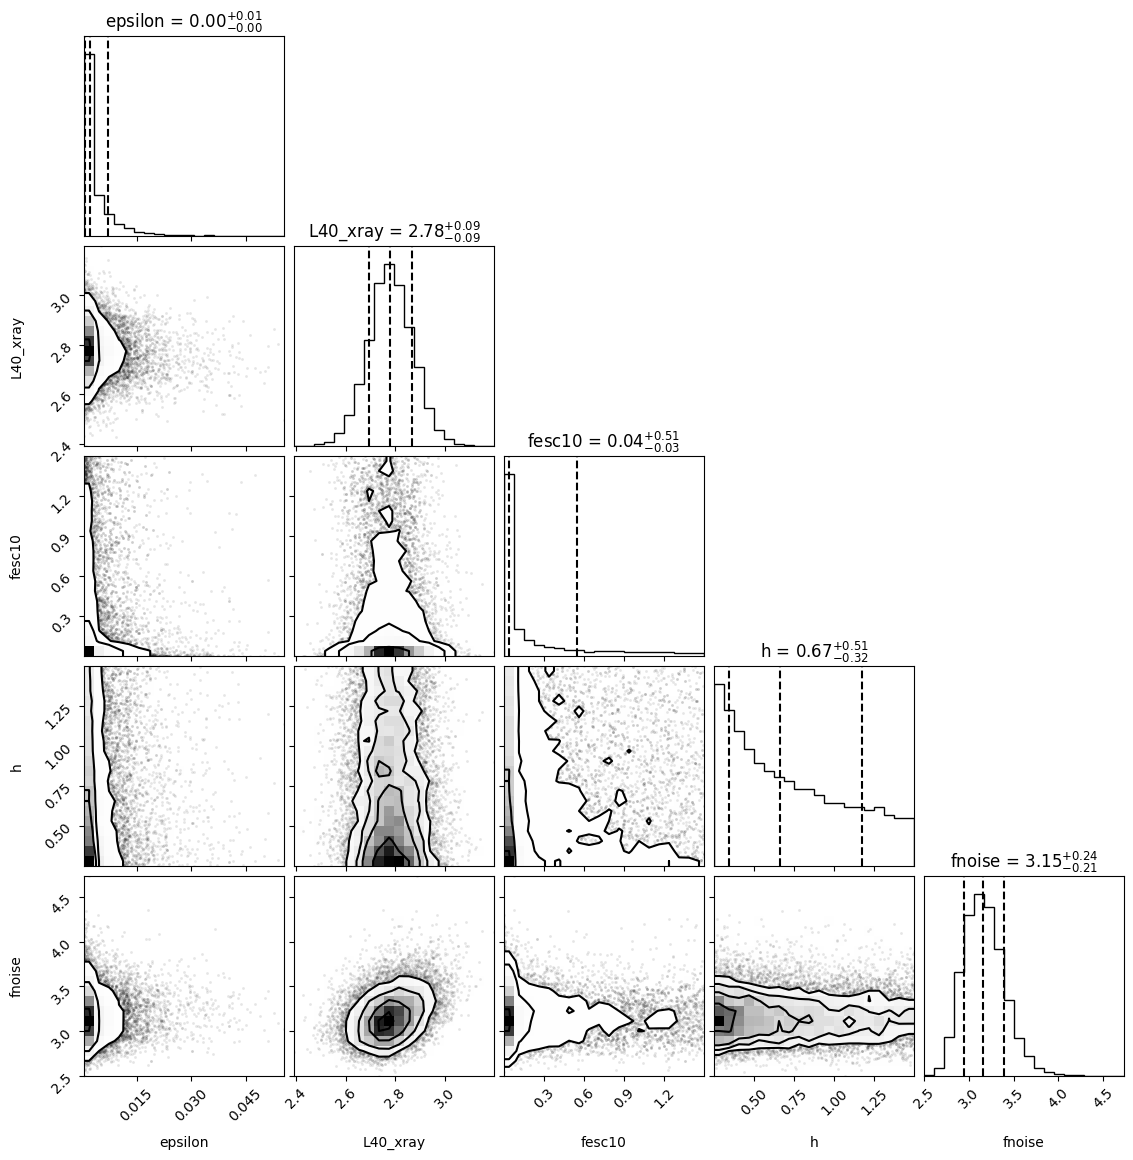

In [24]:
fig, samples = plot_corner(results)

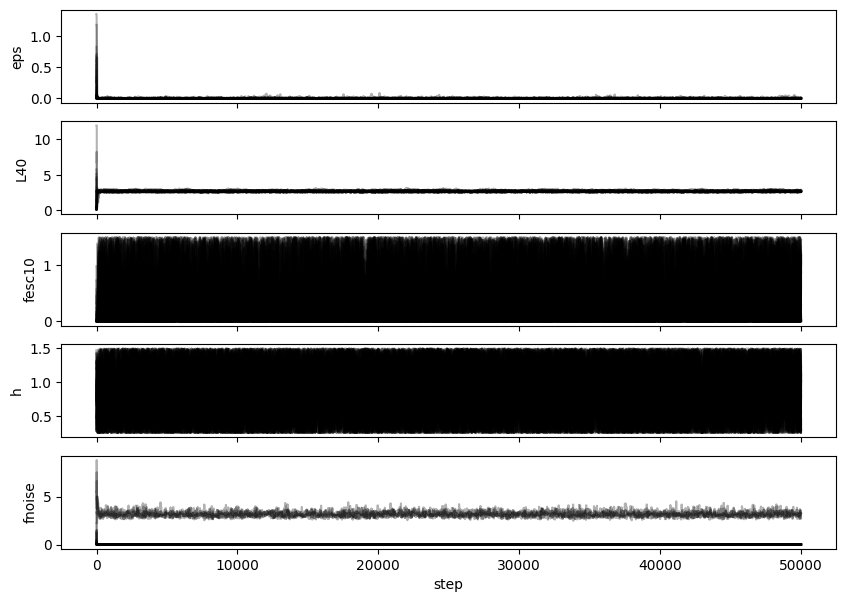

In [ ]:
from helpers.convergence_tests import trace_plot
trace_plot(unthinned_chain)